In [2]:
from model.Wavelet import *
from dataloader import *

In [49]:
train_loader, val_loader, test_loader, n_sensors = load_data(dataset="machine-1-2", window_size=64, stride=10, batch_size=1)

wt = DiscreteWaveletTransform(wavelet="haar", input_length=45)



23694


In [54]:
start = 1260
end = 1305
device = "cpu"
df = test_loader.dataset.df[start:end].T
df = torch.Tensor(df)
df = df.unsqueeze(-1)
df.to(device)


tensor([[[0.2000],
         [0.2300],
         [0.2200],
         ...,
         [0.0400],
         [0.0300],
         [0.0300]],

        [[0.1006],
         [0.1000],
         [0.1082],
         ...,
         [0.0233],
         [0.0220],
         [0.0213]],

        [[0.1150],
         [0.1163],
         [0.1183],
         ...,
         [0.0285],
         [0.0275],
         [0.0272]],

        ...,

        [[0.0000],
         [0.0000],
         [0.0000],
         ...,
         [0.0000],
         [0.0000],
         [0.0000]],

        [[0.0000],
         [0.0000],
         [0.0000],
         ...,
         [0.0000],
         [0.0000],
         [0.0000]],

        [[0.0000],
         [0.0000],
         [0.0000],
         ...,
         [0.0000],
         [0.0000],
         [0.0000]]])

In [55]:

_, coeff = wt(df)

In [60]:
A, D = coeff

A = A[:12]
D = D[:12]



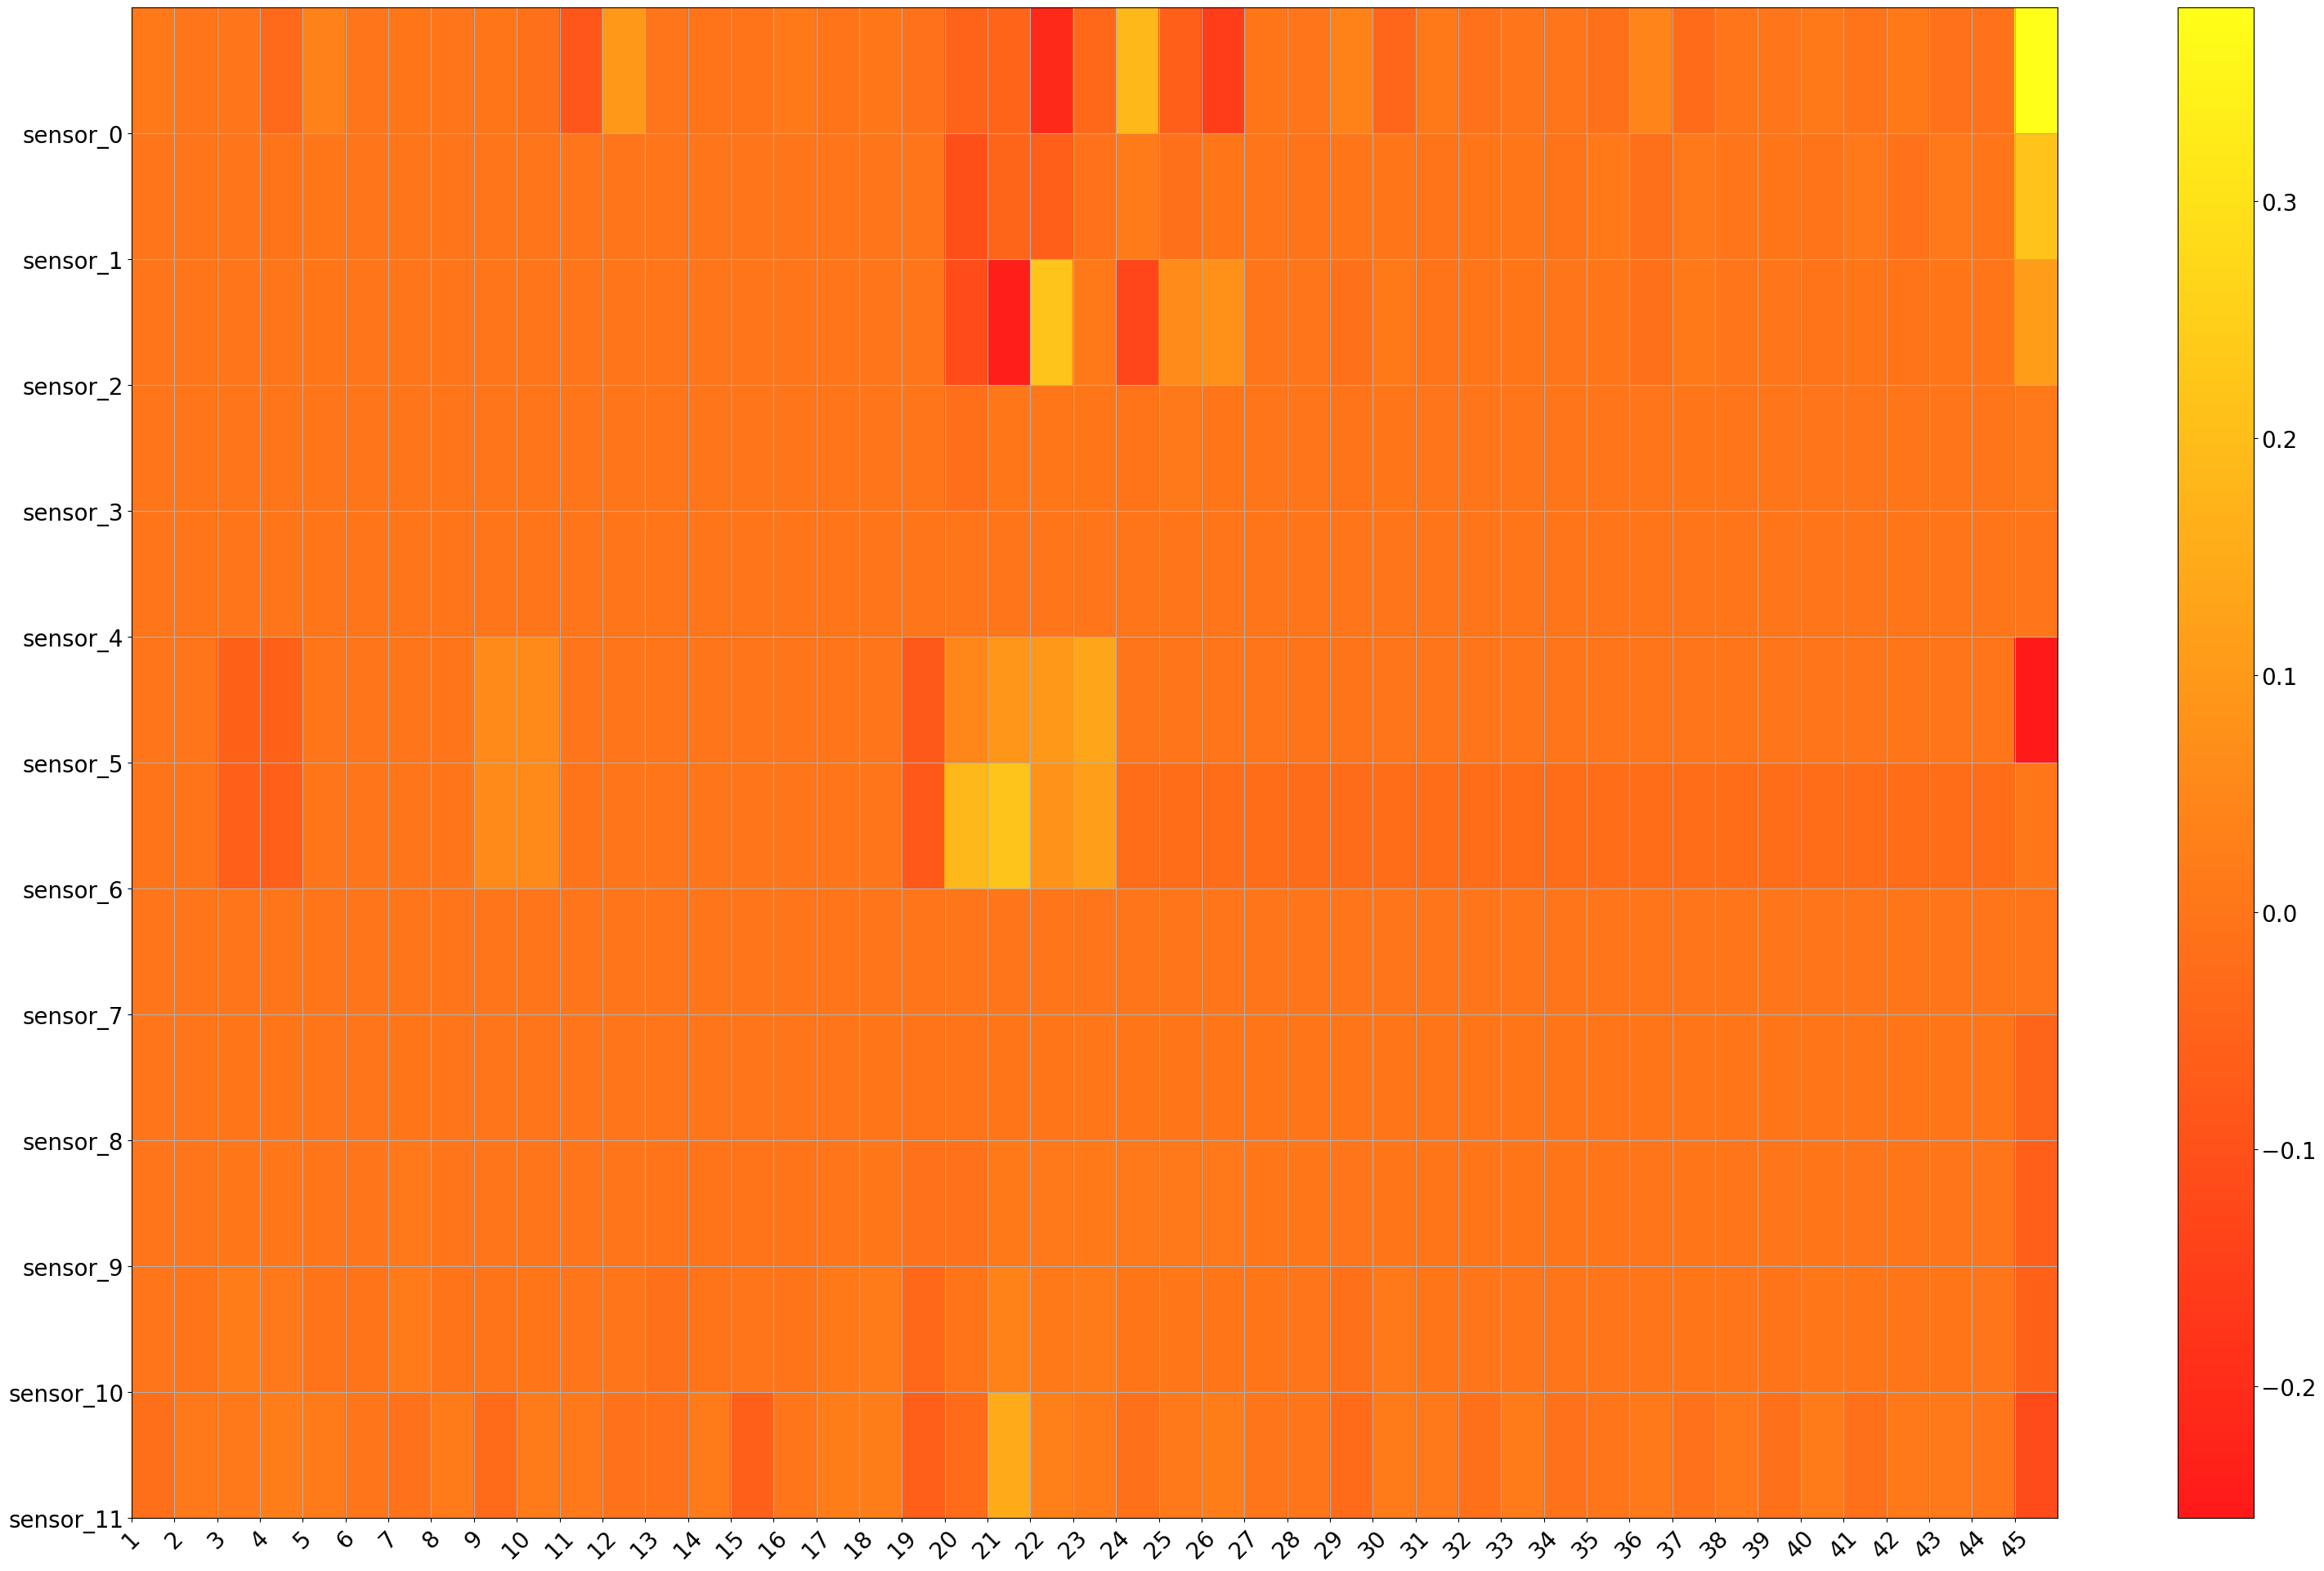

In [63]:
import matplotlib.pyplot as plt 
plt.rcParams['ytick.labelsize'] = 20
X_label = [f'{x + 1}' for x in range(0,45)]
Y_label = [f"sensor_{x}" for x in range(0,12)]
fig, ax = plt.subplots(figsize=(38, 24)) # set figure size
heatmap = ax.pcolor(D, cmap="autumn", alpha=0.9)
fig.colorbar(heatmap)
X_label = [x_label for x_label in X_label]
Y_label = [y_label for y_label in Y_label]
    
xticks = range(0,len(X_label))
ax.set_xticks(xticks, minor=False) # major ticks
ax.set_xticklabels(X_label, minor = False, rotation=45, fontsize=20)   # labels should be 'unicode'
    
yticks = range(0,len(Y_label))
ax.set_yticks(yticks, minor=False)
ax.set_yticklabels(Y_label[::-1], minor = False, fontsize=20)   # labels should be 'unicode'
  
    
ax.grid(True)

plt.savefig("../figures/detail_coefficients.jpeg", dpi=500)

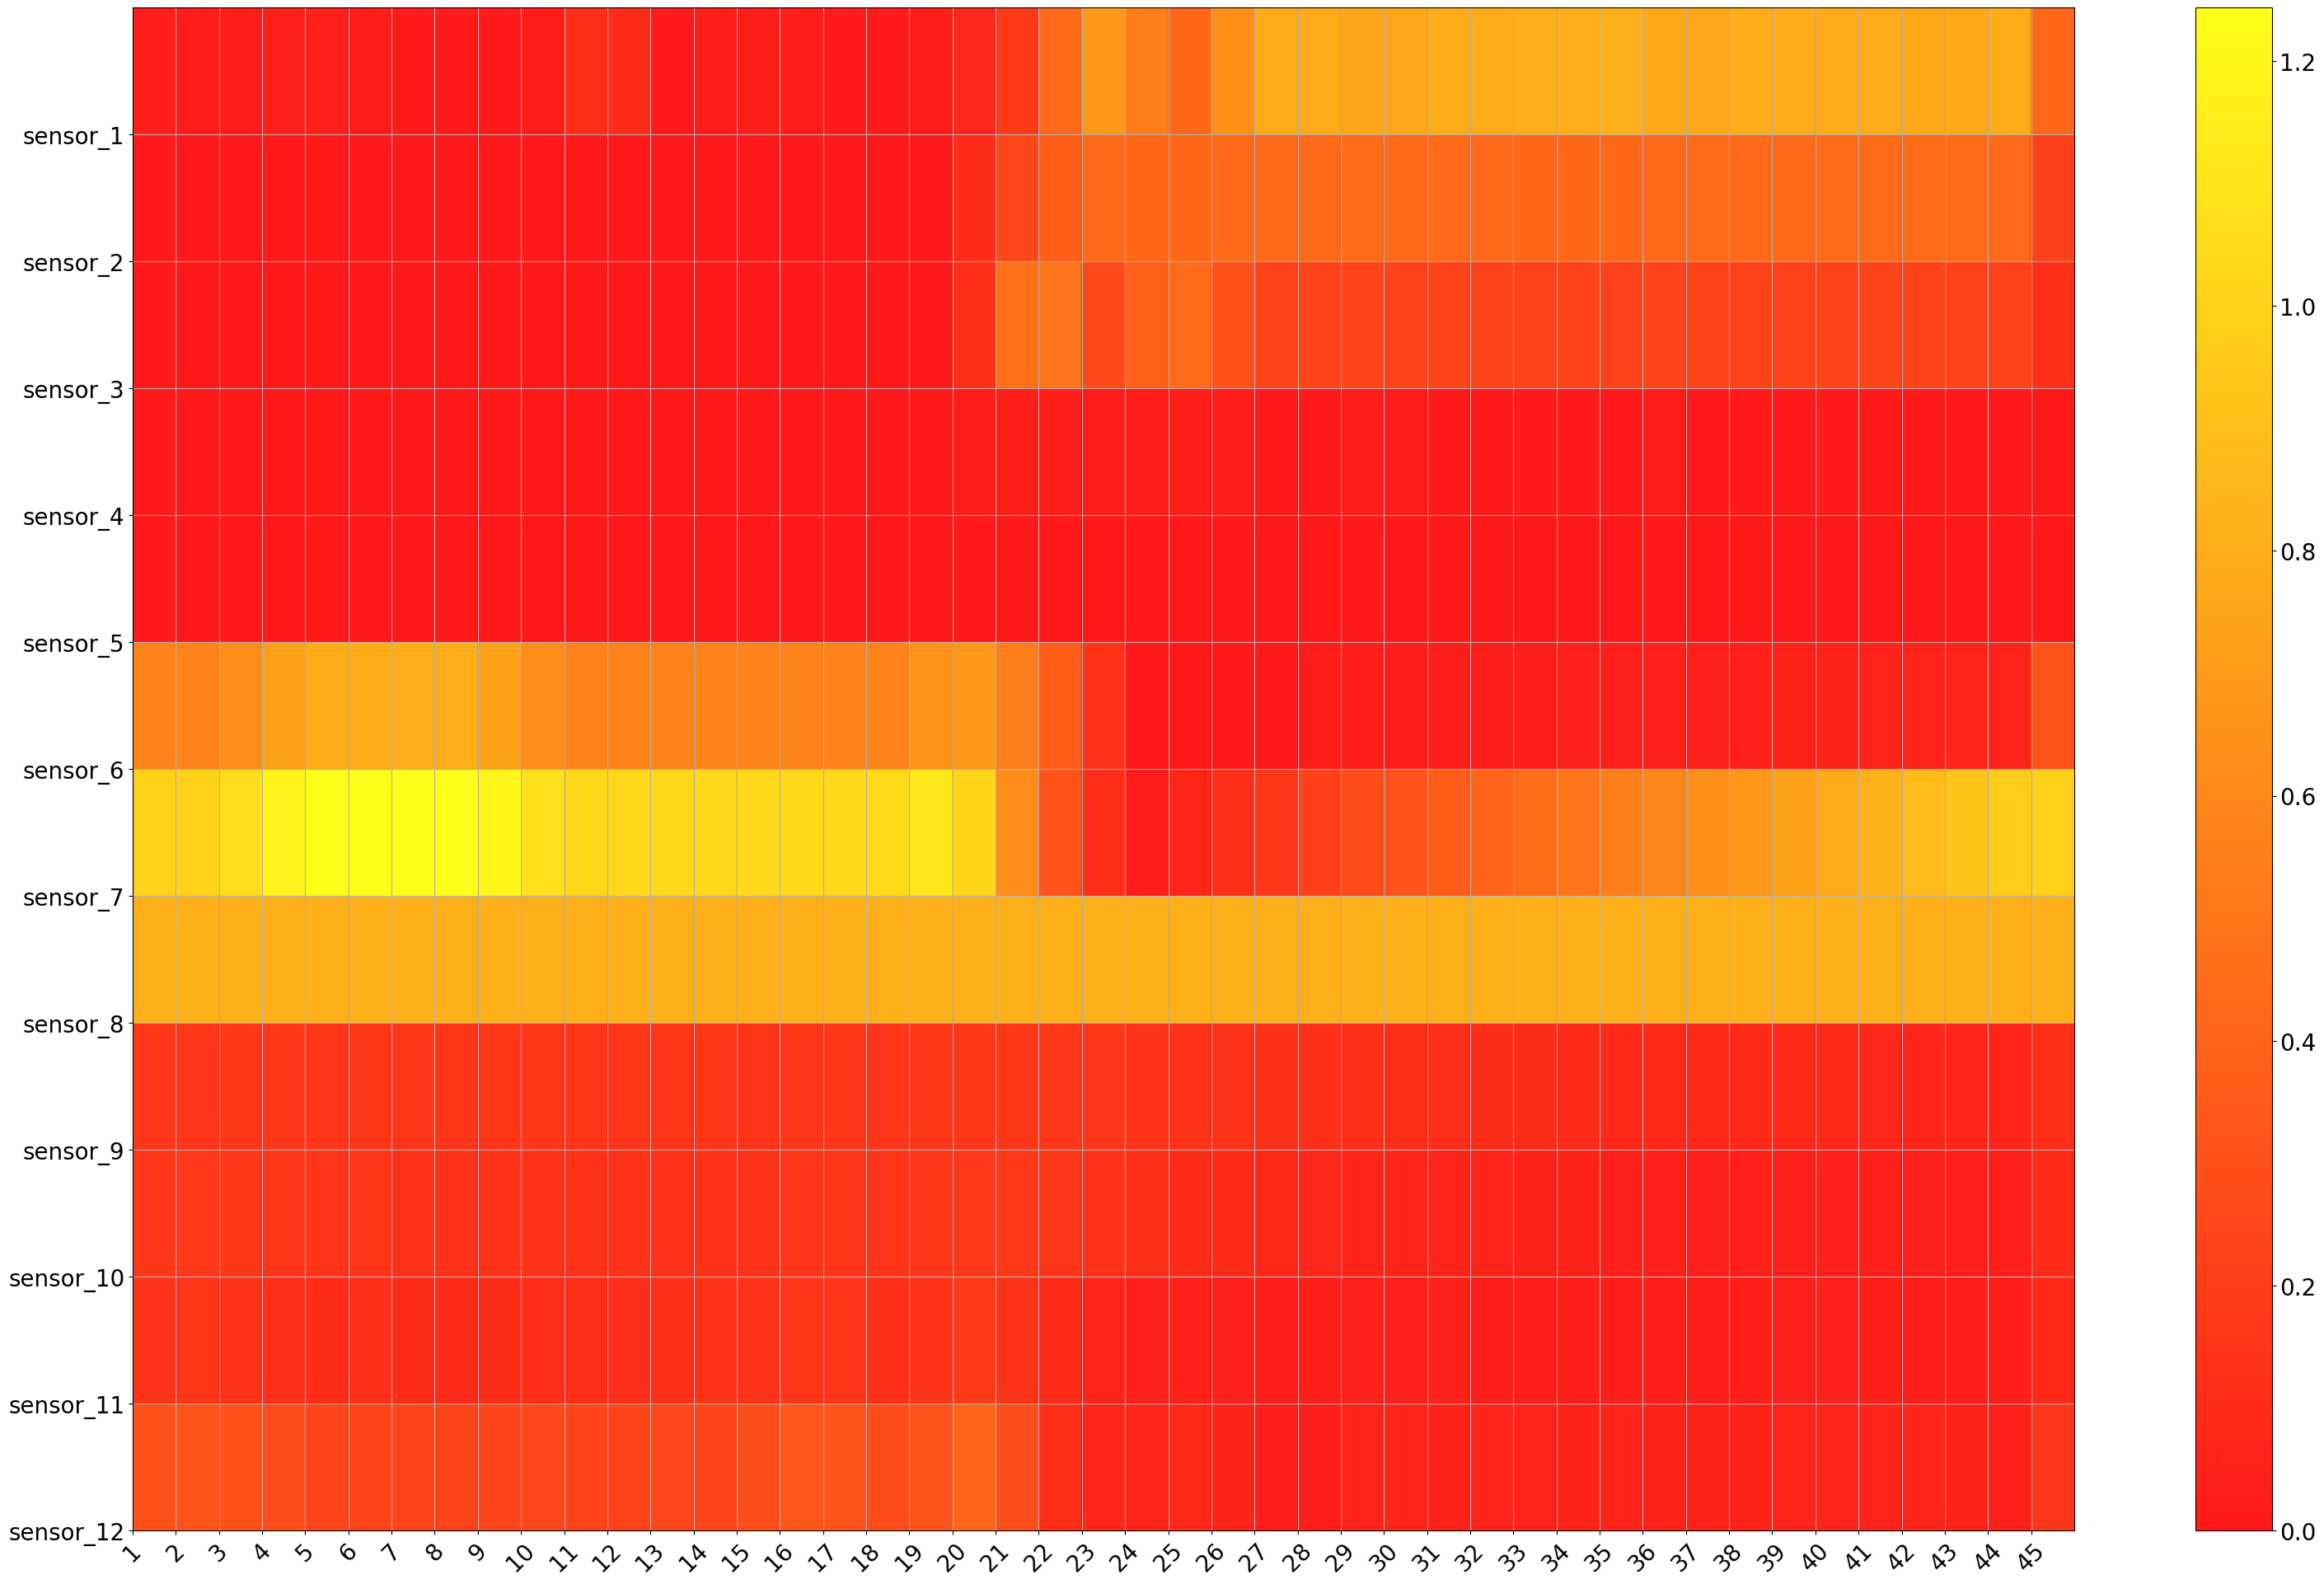

In [64]:
import matplotlib.pyplot as plt 
plt.rcParams['ytick.labelsize'] = 20
X_label = [f'{x + 1}' for x in range(0,45)]
Y_label = [f"sensor_{x + 1}" for x in range(0,12)]
fig, ax = plt.subplots(figsize=(38, 24)) # set figure size
heatmap = ax.pcolor(A, cmap="autumn", alpha=0.9)
fig.colorbar(heatmap)
X_label = [x_label for x_label in X_label]
Y_label = [y_label for y_label in Y_label]
    
xticks = range(0,len(X_label))
ax.set_xticks(xticks, minor=False) # major ticks
ax.set_xticklabels(X_label, minor = False, rotation=45, fontsize=20)   # labels should be 'unicode'
    
yticks = range(0,len(Y_label))
ax.set_yticks(yticks, minor=False)
ax.set_yticklabels(Y_label[::-1], minor = False, fontsize=20)   # labels should be 'unicode'
  
    
ax.grid(True)
#plt.show()
plt.savefig("../figures/approximation_coefficients.jpeg", dpi=500)

In [65]:
import pandas as pd

A = pd.DataFrame(A)

D = pd.DataFrame(D)

A.to_csv("../figures/approx_coeff.csv")
D.to_csv("../figures/detail_coeff.csv")